# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from network import Network
from network_application import NetworkAwareApplication
from NetworkSimulation import NetworkSimulation
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [2]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

In [3]:
from eclypse.placement.strategies import RandomStrategy

print("1. Setting up Infrastructure...")
infra = Network("IoT_Network")

nodi_infrastruttura = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for nodo in nodi_infrastruttura:
    infra.add_node(nodo)


# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_edge("Sensor", "Gateway", bandwidth_mbps=10, length_km=1)

# Core Network Links: 50 Mbps
infra.add_edge("Gateway", "R1", bandwidth_mbps=10, length_km=5)
infra.add_edge("Gateway", "R2", bandwidth_mbps=10, length_km=5)
infra.add_edge("R1", "R2", bandwidth_mbps=10, length_km=2)
infra.add_edge("R1", "R3", bandwidth_mbps=10, length_km=10)
infra.add_edge("R2", "R3", bandwidth_mbps=10, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_edge("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMS:
# Packet Size = 1500 Byte -> Service Time on 10Mbps = 1.2 ms
# Rate = 1 pkt / tick.
# We send every a 0.5ms, but we're busy 1.2ms -> congestion at node R3
app.add_edge("Sensor", "Cloud", packet_size_bytes=1500, packets_per_tick=1)


print("3. Initializing Simulation...")
sim = NetworkSimulation(infra)

strategy = RandomStrategy(seed=42)
sim.register(app, placement_strategy=strategy)

# Execution
df = sim.run_network_ticks(duration_ticks=100, tick_duration_s=0.0005)

print("Simulation completed!")

1. Setting up Infrastructure...
[OSPF] Routing tables recalculated and updated on active nodes.
2. Setting up Application (Video Stream)...
Added edge flow Sensor->Cloud: 1 pkt/tick, size 1500B
3. Initializing Simulation...
17:48:34.125 | WARNING | SimulationConfig - Manual simulation required!
Simulation completed!
17:48:34.125 | WARNING | SimulationConfig - Use 'step()' to advance the simulation, and 'stop()' to interrupt it.
17:48:34.127 | INFO | Simulation - Starting Network Simulation for 100 ticks...
17:48:34.128 | INFO | Simulation - Network Simulation Completed.


In [4]:
df

,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops_Count,Hops_Details
0,1,1,,Sensor,Cloud,0.0000,0.005244,5.244284,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
1,2,2,,Sensor,Cloud,0.0005,0.010194,9.694088,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
2,3,3,,Sensor,Cloud,0.0010,0.010512,9.511516,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
3,4,4,,Sensor,Cloud,0.0015,0.012265,10.765262,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
4,5,5,,Sensor,Cloud,0.0020,0.012368,10.367787,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
...,...,...,...,...,...,...,...,...,...,...
95,96,96,,Sensor,Cloud,0.0475,0.122345,74.845377,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
96,97,97,,Sensor,Cloud,0.0480,0.124064,76.063911,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
97,98,98,,Sensor,Cloud,0.0485,0.126156,77.655572,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
98,99,99,,Sensor,Cloud,0.0490,0.126934,77.934158,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."


In [5]:
all_events = []

# Extract every single hop from the DataFrame
for index, row in df.iterrows():
    packet_id = row['Packet_ID']
    # If the packet has traveled, we extract its individual hops
    if isinstance(row['Hops_Details'], list):
        for hop in row['Hops_Details']:
            all_events.append({
                'time': hop['arrival_at_next'],
                'packet_id': packet_id,
                'event': f"Link: {hop['hop']:^17} | Status: FINISHED | Queue: {hop['queue_length']:>2} pkts"
            })

# We sort ALL events by timestamp (oldest to newest)
all_events_sorted = sorted(all_events, key=lambda x: x['time'])
# Print all the events in chronological order, showing the timestamp, packet ID, and link traversed
for ev in all_events_sorted:
    print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")

[  0.000342s] | Packet: 1     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001304s] | Packet: 1     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.001788s] | Packet: 2     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  0 pkts
[  0.001993s] | Packet: 2     | Link:    Gateway->R1    | Status: FINISHED | Queue:  0 pkts
[  0.002393s] | Packet: 1     | Link:      R1->R3       | Status: FINISHED | Queue:  0 pkts
[  0.002752s] | Packet: 2     | Link:      R1->R3       | Status: FINISHED | Queue:  1 pkts
[  0.005244s] | Packet: 1     | Link:     R3->Cloud     | Status: FINISHED | Queue:  0 pkts
[  0.006578s] | Packet: 3     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  1 pkts
[  0.006697s] | Packet: 4     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  2 pkts
[  0.007328s] | Packet: 5     | Link:  Sensor->Gateway  | Status: FINISHED | Queue:  2 pkts
[  0.007777s] | Packet: 6     | Link:  Sensor->Gateway  | Status: FINISHED | Que

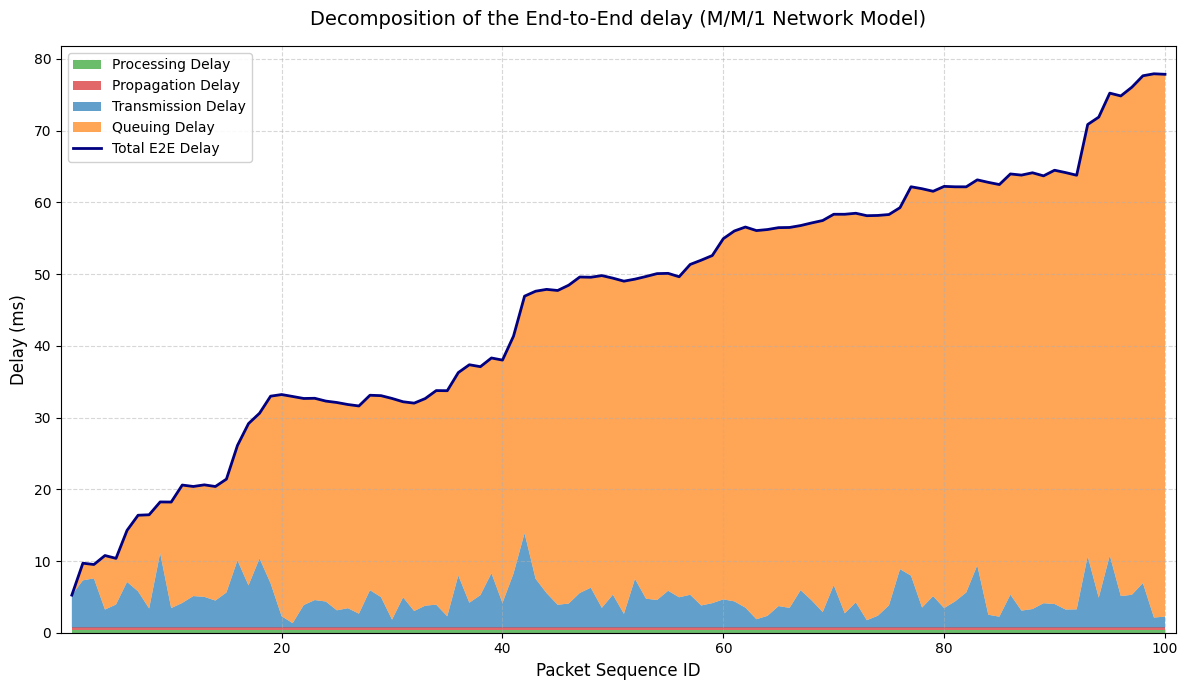


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 1.52 ms
- Queuing:      75.61 ms
--------------------------------
= TOTAL:        77.86 ms


In [6]:
import matplotlib.pyplot as plt

# helper function to sum a specific metric across all hops for a given packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(hop.get(metric_name, 0.0) for hop in hops_list)

# create new columns in the DataFrame for each delay component by summing across all hops
df['Total_Proc_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# create a stack plot to visualize the delay breakdown for each packet
plt.figure(figsize=(12, 7))

# We use plt.stackplot to create a stacked area chart where each layer represents a different delay component. 
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# We add a line above everything to mark the Total Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay (M/M/1 Network Model)", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final control print to see the relative weights on the last package
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {last_pkt['Packet_ID']}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")

# Failure recovery

For this simulation, an infrastructure with instantaneous routing convergence (zero blackout time) was assumed. This choice was made to isolate and study exclusively the latency dynamics introduced by the M/M/1 queuing model during the path change transient, excluding the packet loss phenomenon due to table updates.

In [7]:
# Execute the first 50 ticks
df_part1 = sim.run_network_ticks(duration_ticks=50, tick_duration_s=0.0005)

# Break the link Gateway -> R1. This will force the re-routing of the traffic through R2 and R3, creating congestion on the bottleneck link R3 -> Cloud.
infra.remove_edge("Gateway", "R1")
# Execute the next 50 ticks with the degraded network state 
df_part2 = sim.run_network_ticks(duration_ticks=50, tick_duration_s=0.0005)

df_complete = pd.concat([df_part1, df_part2], ignore_index=True)

[FAILURE] Link Gateway -> R1 has failed and been removed from the network.
[OSPF] Routing tables recalculated and updated on active nodes.
17:48:34.399 | INFO | Simulation - Starting Network Simulation for 50 ticks...
17:48:34.400 | INFO | Simulation - Network Simulation Completed.
17:48:34.401 | INFO | Simulation - Starting Network Simulation for 50 ticks...
17:48:34.402 | INFO | Simulation - Network Simulation Completed.


In [8]:
df_complete

,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops_Count,Hops_Details
0,1,101,,Sensor,Cloud,0.0000,0.128075,128.074657,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
1,2,102,,Sensor,Cloud,0.0005,0.134642,134.142279,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
2,3,103,,Sensor,Cloud,0.0010,0.135995,134.995435,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
3,4,104,,Sensor,Cloud,0.0015,0.136248,134.748142,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
4,5,105,,Sensor,Cloud,0.0020,0.137759,135.759492,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
...,...,...,...,...,...,...,...,...,...,...
95,46,196,,Sensor,Cloud,0.0225,0.263933,241.432843,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
96,47,197,,Sensor,Cloud,0.0230,0.265088,242.088104,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
97,48,198,,Sensor,Cloud,0.0235,0.265597,242.097188,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
98,49,199,,Sensor,Cloud,0.0240,0.265836,241.836038,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."


Given the final dataset (consisting of df_part1 and df_part2), it's now possible to show how the packets transited through the network links in chronological order of arrival.

As can be seen from the 151st packet, the packets transit through the Gateway -> R2 link, since Gateway -> R1 has been removed from the network, but the network was able to immediately recalculate the routing tables.

In [9]:
all_events = []

for index, row in df_complete.iterrows():
    packet_id = row['Packet_ID']
    if isinstance(row['Hops_Details'], list):
        for hop in row['Hops_Details']:
            all_events.append({
                'time': hop['arrival_at_next'],
                'packet_id': packet_id,
                'event': f"Link: {hop['hop']:^17} | Status: FINISHED | Queue: {hop['queue_length']:>2} pkts"
            })

all_events_sorted = sorted(all_events, key=lambda x: x['time'])
for ev in all_events_sorted:
    print(f"[{ev['time']:10.6f}s] | Packet: {ev['packet_id']:<5} | {ev['event']}")

[  0.115309s] | Packet: 101   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 57 pkts
[  0.116181s] | Packet: 102   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 58 pkts
[  0.118095s] | Packet: 101   | Link:    Gateway->R1    | Status: FINISHED | Queue:  4 pkts
[  0.118483s] | Packet: 103   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 59 pkts
[  0.119613s] | Packet: 104   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 60 pkts
[  0.119814s] | Packet: 102   | Link:    Gateway->R1    | Status: FINISHED | Queue:  5 pkts
[  0.120544s] | Packet: 103   | Link:    Gateway->R1    | Status: FINISHED | Queue:  1 pkts
[  0.121098s] | Packet: 104   | Link:    Gateway->R1    | Status: FINISHED | Queue:  2 pkts
[  0.122086s] | Packet: 105   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 61 pkts
[  0.122419s] | Packet: 106   | Link:  Sensor->Gateway  | Status: FINISHED | Queue: 62 pkts
[  0.124219s] | Packet: 107   | Link:  Sensor->Gateway  | Status: FINISHED | Que